1DECISION TREE
Objective:
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.
Tasks:
1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).
2. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.
3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.
4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).
5. Hyperparameter Tuning:
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.
6. Model Evaluation and Analysis:
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features
Interview Questions:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
2. What is the difference between the Label encoding and One-hot encoding?


#NOTES: DECISCION TREE
Analysis-vidya

to control overfitting with help of regularisation, PCA and ensemble technique. to understand ensemble technique we have bagging and boosting . bagging is based on random forest. and to understand random forest we need to understand Decision tree

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Data Preparation: Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [ ]:
df=pd.read_excel('/content/heart_disease - Copy.xlsx')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,fixed defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,fixed defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,fixed defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,normal,4


2. Exploratory Data Analysis (EDA): Perform exploratory data analysis to understand the structure of the dataset. Check for missing values, outliers, and inconsistencies in the data. Visualize the distribution of features, including histograms, box plots, and correlation matrices.

In [ ]:
df.shape

(908, 13)

In [ ]:
df.size

11804

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


<Axes: ylabel='Frequency'>

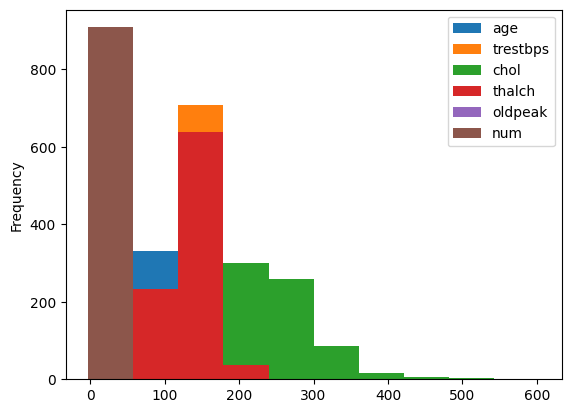

In [ ]:
df.plot(kind='hist') #eather our dat is normally distributedf or not.histogram is only for numerical data but here we have used entire dataset

<Axes: ylabel='Frequency'>

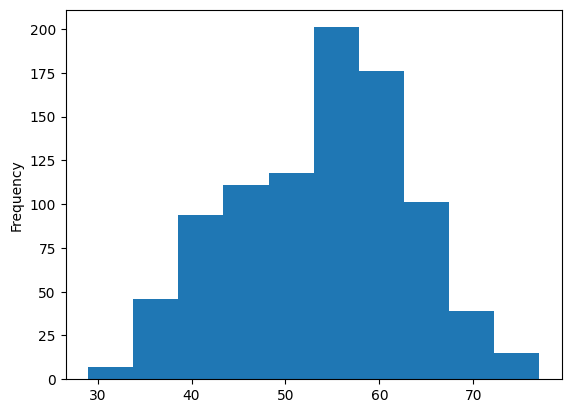

In [ ]:
df['age'].plot(kind='hist') # data is slightly normally distributed

<Axes: xlabel='age', ylabel='Count'>

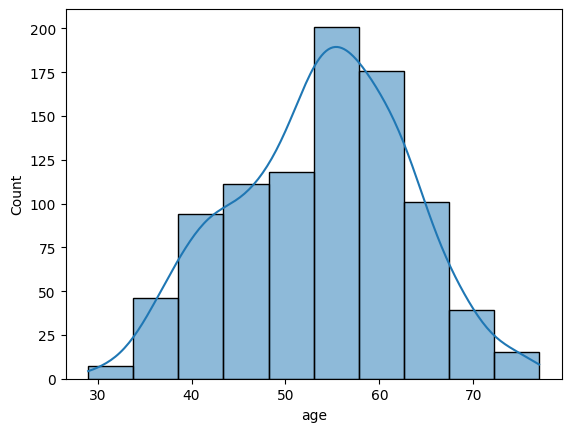

In [ ]:
# or the above can be evn polotted using sns skewnes
sns.histplot(df['age'], bins=10, kde=True) #kde kernel distribution estimation

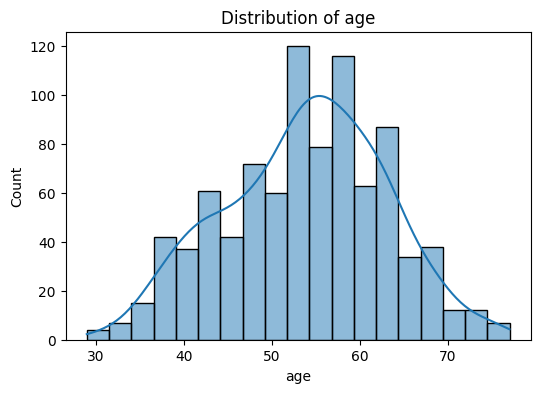

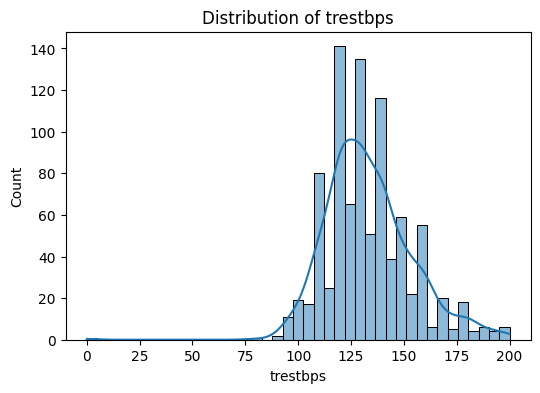

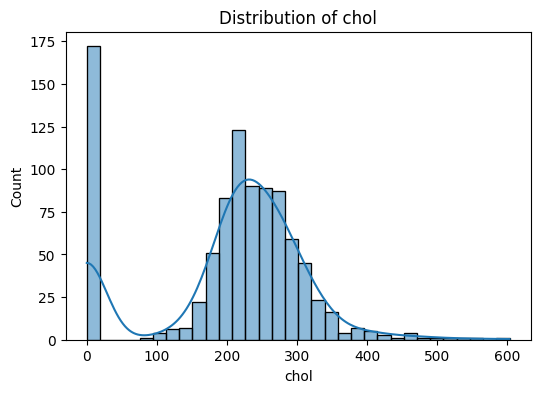

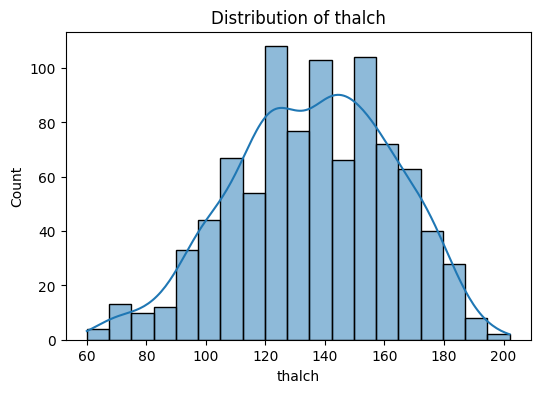

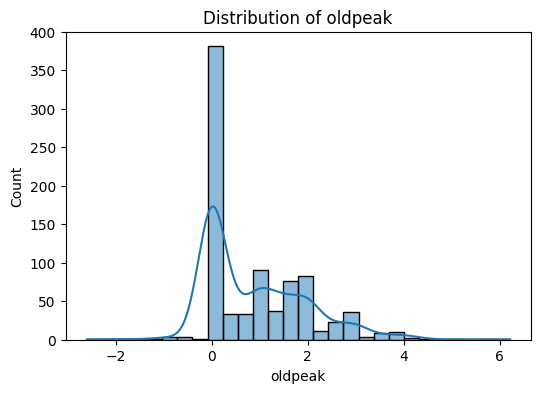

In [ ]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

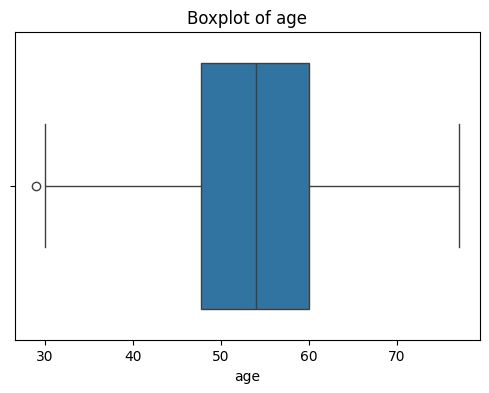

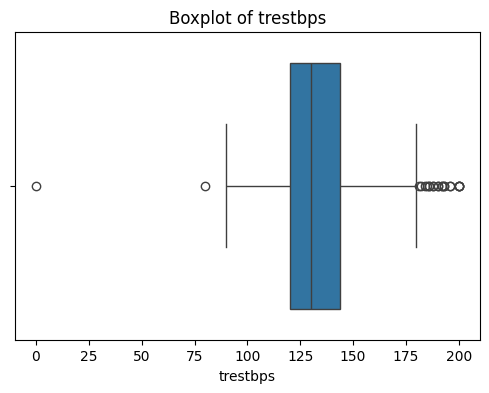

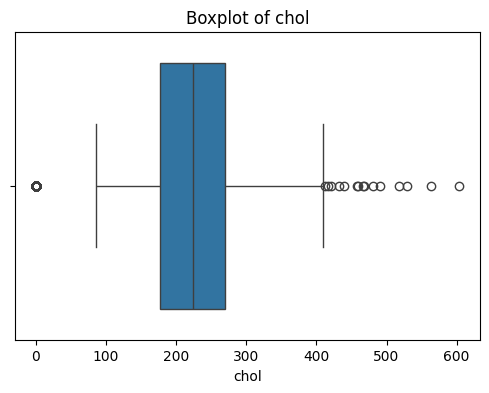

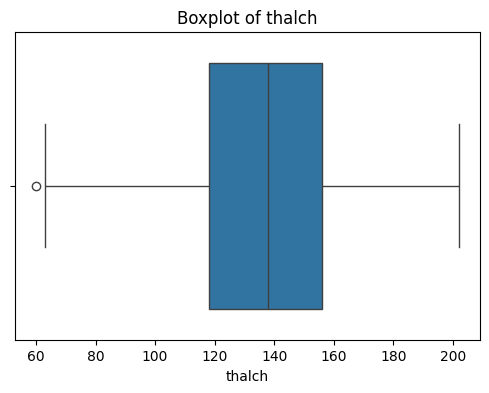

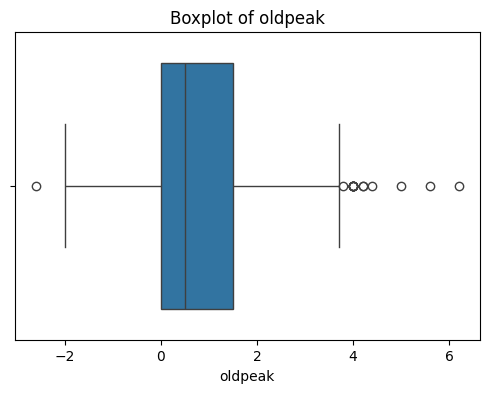

In [ ]:
#box plot can also be plotted as df.plot(kind='box')
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_sc=sc.fit_transform(df[num_cols])
x_sc= pd.DataFrame(x_sc)
x_sc.columns=list(num_cols)
x_sc

,age,trestbps,chol,thalch,oldpeak
0,1.006027,0.567394,0.281297,0.524183,1.288612
1,-1.397560,0.076967,0.013526,-0.147705,-0.815249
2,0.350503,0.322181,-0.084656,0.449529,-0.449360
3,-0.195767,-0.756760,-0.138211,2.017268,-0.815249
4,0.350503,-1.149102,-0.004325,-0.371668,0.556834
...,...,...,...,...,...
903,-0.086513,-0.413461,-1.798388,-0.595631,0.556834
904,0.896773,1.597292,-0.281021,-0.595631,1.928917
905,0.241249,1.793463,-1.798388,-0.483649,1.471556
906,0.241249,0.518352,0.058155,-1.155538,NaN


In [ ]:
x_cat = df[['sex',	'cp',	'fbs',	'restecg', 'exang',		'slope',	'thal']]
x_cat

,sex,cp,fbs,restecg,exang,slope,thal
0,Male,typical angina,True,lv hypertrophy,False,downsloping,fixed defect
1,Male,atypical angina,False,normal,False,flat,fixed defect
2,Male,asymptomatic,False,normal,False,flat,fixed defect
3,Male,typical angina,False,lv hypertrophy,False,flat,fixed defect
4,Male,asymptomatic,False,normal,True,flat,fixed defect
...,...,...,...,...,...,...,...
903,Male,asymptomatic,False,normal,False,upsloping,fixed defect
904,Male,asymptomatic,False,st-t abnormality,True,flat,fixed defect
905,Male,non-anginal,False,lv hypertrophy,True,downsloping,fixed defect
906,Male,non-anginal,True,st-t abnormality,TURE,downsloping,normal


In [ ]:
#from sklearn.preprocessing import LabelEncoder
#le=LabelEncoder()
#le.fit_transform('x_cat') #fit transform it takes inly 1d array and only one column so x_cat is multiple column

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x_cat['sex']=le.fit_transform(x_cat['sex']) #this value changes only for sex column but to change for all copy paste see next tab
x_cat

/tmp/ipykernel_2492/1746211326.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_cat['sex']=le.fit_transform(x_cat['sex']) #this value changes only for sex column but to change for all copy paste see next tab


,sex,cp,fbs,restecg,exang,slope,thal
0,1,typical angina,True,lv hypertrophy,False,downsloping,fixed defect
1,1,atypical angina,False,normal,False,flat,fixed defect
2,1,asymptomatic,False,normal,False,flat,fixed defect
3,1,typical angina,False,lv hypertrophy,False,flat,fixed defect
4,1,asymptomatic,False,normal,True,flat,fixed defect
...,...,...,...,...,...,...,...
903,1,asymptomatic,False,normal,False,upsloping,fixed defect
904,1,asymptomatic,False,st-t abnormality,True,flat,fixed defect
905,1,non-anginal,False,lv hypertrophy,True,downsloping,fixed defect
906,1,non-anginal,True,st-t abnormality,TURE,downsloping,normal


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

# Convert 'exang' to string type using .apply(str) and correct typos to ensure uniform type
x_cat['exang'] = x_cat['exang'].apply(str).replace({'TURE': 'True', 'FALSE': 'False'})

x_cat['sex']=le.fit_transform(x_cat['sex'])
x_cat['cp']=le.fit_transform(x_cat['cp'])
x_cat['fbs']=le.fit_transform(x_cat['fbs'])
x_cat['restecg']=le.fit_transform(x_cat['restecg'])
x_cat['exang']=le.fit_transform(x_cat['exang'])
x_cat['slope']=le.fit_transform(x_cat['slope'])
x_cat['thal']=le.fit_transform(x_cat['thal'])
x_cat

/tmp/ipykernel_2492/2205196487.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_cat['exang'] = x_cat['exang'].apply(str).replace({'TURE': 'True', 'FALSE': 'False'})
/tmp/ipykernel_2492/2205196487.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_cat['sex']=le.fit_transform(x_cat['sex'])
/tmp/ipykernel_2492/2205196487.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

,sex,cp,fbs,restecg,exang,slope,thal
0,1,3,1,0,0,0,0
1,1,1,0,1,0,1,0
2,1,0,0,1,0,1,0
3,1,3,0,0,0,1,0
4,1,0,0,1,1,1,0
...,...,...,...,...,...,...,...
903,1,0,0,1,0,2,0
904,1,0,0,2,1,1,0
905,1,2,0,0,1,0,0
906,1,2,1,2,1,0,1


In [ ]:
x_sc

,age,trestbps,chol,thalch,oldpeak
0,1.006027,0.567394,0.281297,0.524183,1.288612
1,-1.397560,0.076967,0.013526,-0.147705,-0.815249
2,0.350503,0.322181,-0.084656,0.449529,-0.449360
3,-0.195767,-0.756760,-0.138211,2.017268,-0.815249
4,0.350503,-1.149102,-0.004325,-0.371668,0.556834
...,...,...,...,...,...
903,-0.086513,-0.413461,-1.798388,-0.595631,0.556834
904,0.896773,1.597292,-0.281021,-0.595631,1.928917
905,0.241249,1.793463,-1.798388,-0.483649,1.471556
906,0.241249,0.518352,0.058155,-1.155538,NaN


In [ ]:
x_cat

,sex,cp,fbs,restecg,exang,slope,thal
0,1,3,1,0,0,0,0
1,1,1,0,1,0,1,0
2,1,0,0,1,0,1,0
3,1,3,0,0,0,1,0
4,1,0,0,1,1,1,0
...,...,...,...,...,...,...,...
903,1,0,0,1,0,2,0
904,1,0,0,2,1,1,0
905,1,2,0,0,1,0,0
906,1,2,1,2,1,0,1


In [ ]:
df1=pd.concat([x_sc,x_cat], axis=1)
df1

,age,trestbps,chol,thalch,oldpeak,sex,cp,fbs,restecg,exang,slope,thal
0,1.006027,0.567394,0.281297,0.524183,1.288612,1,3,1,0,0,0,0
1,-1.397560,0.076967,0.013526,-0.147705,-0.815249,1,1,0,1,0,1,0
2,0.350503,0.322181,-0.084656,0.449529,-0.449360,1,0,0,1,0,1,0
3,-0.195767,-0.756760,-0.138211,2.017268,-0.815249,1,3,0,0,0,1,0
4,0.350503,-1.149102,-0.004325,-0.371668,0.556834,1,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
903,-0.086513,-0.413461,-1.798388,-0.595631,0.556834,1,0,0,1,0,2,0
904,0.896773,1.597292,-0.281021,-0.595631,1.928917,1,0,0,2,1,1,0
905,0.241249,1.793463,-1.798388,-0.483649,1.471556,1,2,0,0,1,0,0
906,0.241249,0.518352,0.058155,-1.155538,NaN,1,2,1,2,1,0,1


In [ ]:
x=df1.iloc[:,:]
y = df['num']

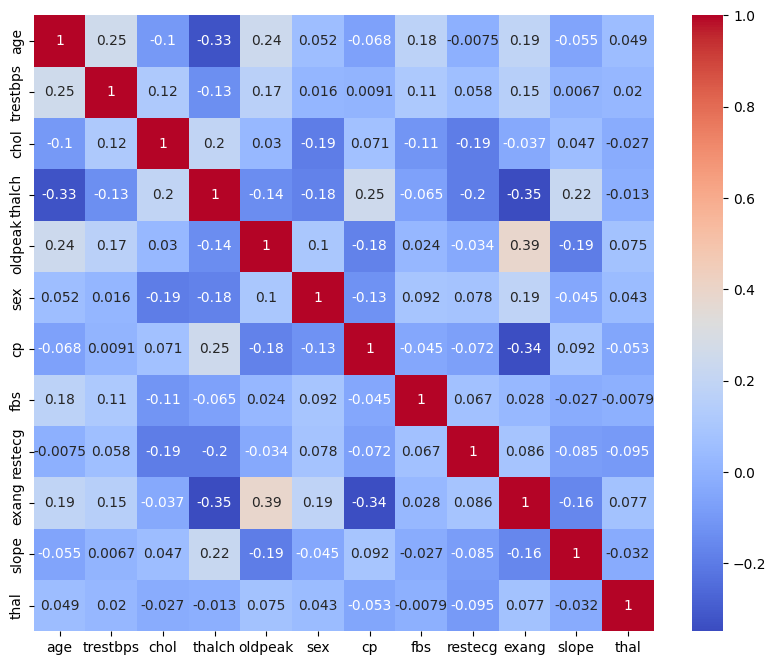

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df1.corr(), annot=True, cmap='coolwarm')
plt.show()

4.Decision Tree Classification: Split the dataset into training and testing sets (e.g., using an 80-20 split). Implement a Decision Tree Classification model using a library like scikit-learn. Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion='gini')
model.fit(x_train,y_train)


DecisionTreeClassifier()

In [ ]:
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

train_acc=accuracy_score(y_train,y_pred_train)
test_acc=accuracy_score(y_test,y_pred_test)
print('training accuracy:', train_acc)
print('testing accuracy:', test_acc)

SyntaxError: invalid syntax (1783008805.py, line 1)

precision, recall and f1 score

In [ ]:
recall=recall_score(y_test,y_pred_test, average='weighted')
print('recall_score:',recall)
precision=precision_score(y_test,y_pred_test, average='weighted')
print('precision_score:',precision)
f1=f1_score(y_test,y_pred_test, average='weighted')
print('f1_score:',f1)

recall_score: 0.43956043956043955
precision_score: 0.4358572675772974
f1_score: 0.43739643146084173


In [ ]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, model.predict_proba(x_test), multi_class='ovr')
print("ROC-AUC:", roc)

# The second call is already correct, but storing it in a variable makes it more useful.
# For example, you might want to compare it with 'roc'
# roc_auc_score(y_test, model.predict_proba(x_test), multi_class='ovr')

ROC-AUC: 0.6486515252050601


In [ ]:
cm=confusion_matrix(y_test,y_pred_test)
cm

array([[53, 16,  3,  3,  1],
       [16, 19,  9,  9,  2],
       [ 4,  9,  4,  3,  2],
       [ 6,  6,  6,  4,  1],
       [ 0,  1,  2,  3,  0]])

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#cross calidation using shuffle split
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion='gini')

from sklearn.model_selection import ShuffleSplit, cross_validate
shuffle_split=ShuffleSplit(n_splits=200, test_size=0.2, random_state=42)

cv_results=cross_validate(model,x,y, cv=shuffle_split, scoring='accuracy', return_train_score=True)

train_scores=cv_results['train_score']
test_score=cv_results['test_score']

print('cross validation: train acc:', np.round(train_scores.mean(),2))
print('cross validation: test acc:', np.round(test_score.mean(),2))

cross validation: train acc: 1.0
cross validation: test acc: 0.48


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth':[3,5,10],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(x_train, y_train)

print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [ ]:
from sklearn.tree import DecisionTreeClassifier
n_nodes = model.tree_.node_count
depth = model.tree_.max_depth

print(f'Number of nodes: {n_nodes}')
print(f'Depth of tree: {depth}')

Number of nodes: 229
Depth of tree: 8


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion='gini',max_depth=8)
model.fit(x_train,y_train)

y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

from sklearn.metrics import accuracy_score

train_acc=accuracy_score(y_train,y_pred_train)
test_acc=accuracy_score(y_test,y_pred_test)
print('training accuracy:', train_acc)
print('testing accuracy:', test_acc)

training accuracy: 0.7947658402203857
testing accuracy: 0.4725274725274725


In [ ]:
#cross calidation using shuffle split
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion='gini',max_depth=8)

from sklearn.model_selection import ShuffleSplit, cross_validate
shuffle_split=ShuffleSplit(n_splits=200, test_size=0.2, random_state=42)

cv_results=cross_validate(model,x,y, cv=shuffle_split, scoring='accuracy', return_train_score=True)

train_scores=cv_results['train_score']
test_score=cv_results['test_score']

print('cross validation: train acc:', np.round(train_scores.mean(),2))
print('cross validation: test acc:', np.round(test_score.mean(),2))

cross validation: train acc: 0.82
cross validation: test acc: 0.51


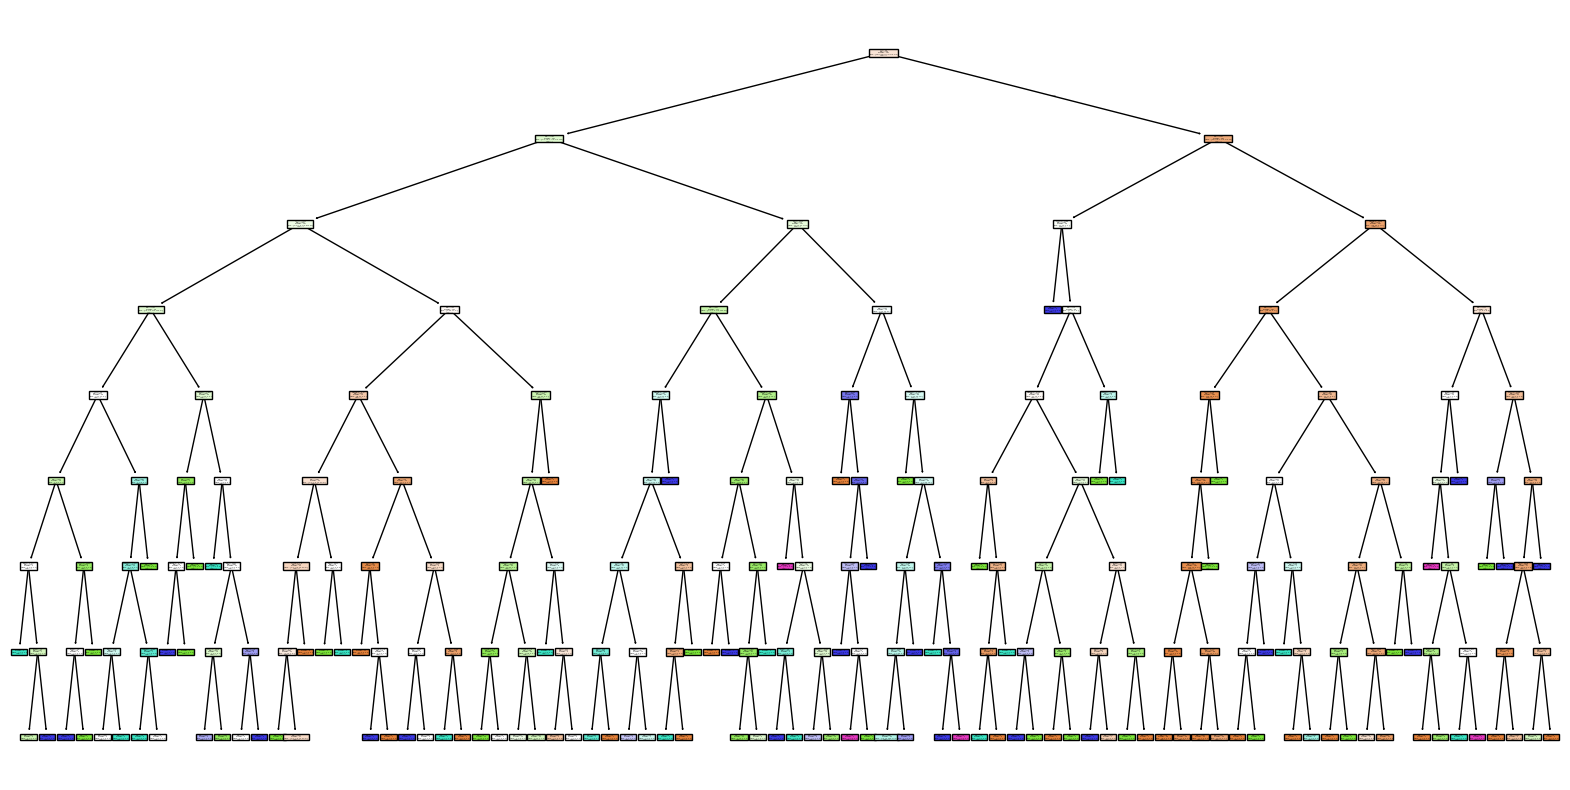

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

model.fit(x_train,y_train)
plt.figure(figsize=(20,10))
plot_tree(
    model,
    filled=True,
    feature_names=x.columns,
    class_names=[str(c) for c in sorted(y.unique())],
)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
n_nodes = model.tree_.node_count
depth = model.tree_.max_depth

print(f'Number of nodes: {n_nodes}')
print(f'Depth of tree: {depth}')

Number of nodes: 229
Depth of tree: 8


7. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
hyperparameter:
max_depth	Controls tree depth
min_samples_split	Controls node splitting
min_samples_leaf	Minimum samples in leaf node
criterion	Split quality method
max_features	Number of features considered

Effect on Performance
Deep trees may overfit.
Small trees may underfit.
Proper tuning improves accuracy.

8.What is the difference between the Label encoding and One-hot encoding?

Label encoder converts categories into numbers example make =0, female=1 and is suitable for ordinal data. it may create false order

one hot encoder create separate binary column ex:Male=[1,0], Female=[0,1] and is suitable for nominal data. there is nor order relatioship